In [1]:
import pandas as pd
import datetime as dt
from netCDF4 import Dataset
import scipy as scp
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp
import os
import glob
import re
from scipy.ndimage import uniform_filter
from scipy.interpolate import RectBivariateSpline, InterpolatedUnivariateSpline
import argparse
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from multiprocessing import Pool
from netCDF4 import Dataset
import matplotlib as mpl
import matplotlib.cm 
import os
from scipy.signal import windows
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import cartopy
import numpy as np
import matplotlib.ticker as mticker
from cartopy import crs
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import xarray as xr
from matplotlib.lines import Line2D

In [2]:
def maps(x, y, minn, maxx, matriz,  cmap, path, xlim='', ylim='', x_scatter='', y_scatter='', units='', topography = '', center_lon=180, steps=15):

    import matplotlib.pyplot as plt
    import cartopy
    from cartopy import crs
    import numpy as np
    import matplotlib.ticker as mticker

    fig = plt.figure(figsize=[6, 4])
    ax = fig.add_subplot(1, 1, 1, projection=crs.PlateCarree(central_longitude=center_lon))
    
    if topography == True:
        # ax.add_feature(cartopy.feature.BORDERS, lw=0.5)
        ax.add_feature(cartopy.feature.COASTLINE, lw=0.5, zorder=11)

    im = ax.contourf(x, y[:], matriz[:,:], levels=np.linspace(minn, maxx, steps), cmap = cmap, extend='both', transform=crs.PlateCarree())

    # Avoid `if x_scatter:` (ambiguous for arrays) and `arr != ''` (returns bool array).
    if x_scatter is not None and not (isinstance(x_scatter, str) and x_scatter == ''):
        if np.size(np.asanyarray(x_scatter)) > 0:
            ax.scatter(x_scatter, y_scatter, s=0.8, marker='x', color='k', transform=crs.PlateCarree())

    if np.any(y>50): 
        ax.set_yticks([25,50,75])
        ax.set_yticklabels(['25°N', '50°N', '75°N'])
    else: 
        ax.set_yticks([30,40,50])
        ax.set_yticklabels(['30°N', '40°N', '50°N'])
    ax.tick_params(axis='both', labelsize=8)
    gl = ax.gridlines(crs=crs.PlateCarree(), draw_labels=True,
                      linewidth=0.7, color='gray', alpha=0.2, linestyle='--')

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator([25,50,75])
    # gl.yformatter = mticker.FuncFormatter(lambda x, p: f'{abs(x):.0f}°N' if x >= 0 else f'{abs(x):.0f}°S')
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    if ylim is not None:
        plt.ylim(ylim[0],ylim[1])
    if xlim is not None:
        plt.xlim(xlim[0],xlim[1])
    
    cb = plt.colorbar(im, orientation="horizontal", pad=0.08, format='%.2f', shrink=0.9, aspect=40)
    cb.set_label(units, fontsize=8, color='k')
    cb.ax.tick_params(labelsize=8)
    plt.subplots_adjust(
                bottom=0.2,
                top=0.995,
                wspace=0.1,
                hspace=0.3)
    # plt.savefig(path, dpi=500)
    plt.show()
    plt.close()


def maps_classification(x, y, minn, maxx, matriz, cmap, path, xlim='', ylim='', x_scatter='', y_scatter='', units='', topography='', center_lon=180):
    """Plot integer class labels minn..maxx (e.g. 0–4). Colorbar shows class IDs centered in each band; no over/under triangles."""

    import matplotlib.pyplot as plt
    import cartopy
    from cartopy import crs
    import numpy as np
    import matplotlib.ticker as mticker

    fig = plt.figure(figsize=[6, 4])
    ax = fig.add_subplot(1, 1, 1, projection=crs.PlateCarree(central_longitude=center_lon))

    if topography == True:
        ax.add_feature(cartopy.feature.COASTLINE, lw=0.5, zorder=11)
        ax.add_feature(cartopy.feature.BORDERS, lw=0.5, zorder=11)
        ax.add_feature(cartopy.feature.STATES, lw=0.5, zorder=11)

    # Boundaries halfway between integers so each class maps to one filled level
    bounds = np.arange(float(minn) - 0.5, float(maxx) + 1.0, 1.0)
    im = ax.contourf(
        x,
        y[:],
        matriz[:, :],
        levels=bounds,
        cmap=cmap,
        extend='neither',
        transform=crs.PlateCarree(),
    )

    if x_scatter is not None and not (isinstance(x_scatter, str) and x_scatter == ''):
        if np.size(np.asanyarray(x_scatter)) > 0:
            print("plotting scatter")
            ax.scatter(x_scatter, y_scatter, s=6.5, marker='x', color='red', transform=crs.PlateCarree())

    if np.any(y > 50):
        ax.set_yticks([25, 50, 75])
        ax.set_yticklabels(['25°N', '50°N', '75°N'])
    else:
        ax.set_yticks([30, 40, 50])
        ax.set_yticklabels(['30°N', '40°N', '50°N'])
    ax.tick_params(axis='both', labelsize=8)
    gl = ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=0.7,
        color='gray',
        alpha=0.2,
        linestyle='--',
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator([25, 50, 75])
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    if ylim is not None and ylim != '':
        plt.ylim(ylim[0], ylim[1])
    if xlim is not None and xlim != '':
        plt.xlim(xlim[0], xlim[1])

    tick_vals = np.arange(int(minn), int(maxx) + 1)
    cb = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        pad=0.08,
        ticks=tick_vals,
        extend='neither',
        shrink=0.9,
        aspect=40,
        format='%d',
    )
    cb.set_label(units, fontsize=8, color='k')
    cb.ax.tick_params(labelsize=8)

    plt.subplots_adjust(bottom=0.2, top=0.995, wspace=0.1, hspace=0.3)
    # plt.savefig(path, dpi=500)
    plt.show()
    plt.close()


def colormap_custom(min_v, max_v, steps, colors):
    norm_values = np.linspace(0, 1, len(colors))
    bar_vals = list(zip(norm_values, colors))
    custom_cmap = mpl.colors.LinearSegmentedColormap.from_list("custom", bar_vals)
    return min_v, max_v, steps,custom_cmap

def extract_latlons_from_coord_events(coord_events):
    """
    Given a pandas Series of position strings as in df_heatwaves.iloc[:,4],
    returns a tuple of arrays: (lats, lons)
    """
    import numpy as np

    def parse_position(pos_str):
        # Remove possible quotes and white spaces
        s = pos_str.strip().strip('"').strip("'").strip('[]')
        items = s.split('),')
        lat = float(items[0].split('(')[-1])
        lon = float(items[1].split('(')[-1].replace(')', ''))
        return lat, lon

    lats, lons = [], []
    for pos_str in coord_events:
        lat, lon = parse_position(pos_str)
        lats.append(lat)
        lons.append(lon)
    return np.array(lats), np.array(lons)


def lon_to_relative(lon, center_lon):
    """
    Convert lon (0–360) to relative longitude [-180, 180]
    """
    rel = lon - center_lon
    return (rel + 180) % 360 - 180

def maps_dots(x, y, minn, maxx, matriz, cmap, path, xlim='', ylim='', x_scatter='', y_scatter='', units='', topography='', center_lon=180):
    """Plot integer class labels minn..maxx (e.g. 0–4). Colorbar shows class IDs centered in each band; no over/under triangles."""

    import matplotlib.pyplot as plt
    import cartopy
    from cartopy import crs
    import numpy as np
    import matplotlib.ticker as mticker

    fig = plt.figure(figsize=[6, 4])
    ax = fig.add_subplot(1, 1, 1, projection=crs.PlateCarree(central_longitude=center_lon))

    if topography == True:
        ax.add_feature(cartopy.feature.COASTLINE, lw=0.5, zorder=11)

    # Boundaries halfway between integers so each class maps to one filled level
    bounds = np.arange(float(minn) - 0.5, float(maxx) + 1.0, 1.0)
    im = ax.contourf(
        x,
        y[:],
        matriz[:, :],
        levels=bounds,
        cmap=cmap,
        extend='neither',
        transform=crs.PlateCarree(),
    )

    if x_scatter is not None and not (isinstance(x_scatter, str) and x_scatter == ''):
        if np.size(np.asanyarray(x_scatter)) > 0:
            print("plotting scatter")
            ax.scatter(x_scatter, y_scatter, s=3, marker='x', color='brown', transform=crs.PlateCarree())

    if np.any(y > 50):
        ax.set_yticks([25, 50, 75])
        ax.set_yticklabels(['25°N', '50°N', '75°N'])
    else:
        ax.set_yticks([30, 40, 50])
        ax.set_yticklabels(['30°N', '40°N', '50°N'])
    ax.tick_params(axis='both', labelsize=8)
    gl = ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=0.7,
        color='gray',
        alpha=0.2,
        linestyle='--',
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator([25, 50, 75])
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    if ylim is not None and ylim != '':
        plt.ylim(ylim[0], ylim[1])
    if xlim is not None and xlim != '':
        plt.xlim(xlim[0], xlim[1])

    tick_vals = np.arange(int(minn), int(maxx) + 1)
    cb = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        pad=0.08,
        ticks=tick_vals,
        extend='neither',
        shrink=0.9,
        aspect=40,
        format='%d',
    )
    cb.set_label(units, fontsize=8, color='k')
    cb.ax.tick_params(labelsize=8)

    plt.subplots_adjust(bottom=0.2, top=0.995, wspace=0.1, hspace=0.3)
    # plt.savefig(path, dpi=500)
    plt.show()
    plt.close()

def maps_EOF(Matriz, lats, lons, min, max, cmap, pcvars, path, topography, var = ''):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from cartopy import crs
    fig = plt.figure(figsize=[15, 18])
    for i, tit in enumerate(['EOF1', 'EOF2', 'EOF3', 'EOF4', 'EOF5']):
        ax = fig.add_subplot(5, 1, i + 1, projection=crs.PlateCarree(central_longitude=180))
        if topography == True:
            ax.add_feature(cartopy.feature.COASTLINE, lw=0.6, zorder=11)
        im = ax.contourf(lons, lats, Matriz[i, :, :], cmap=cmap, extend='both',
                         levels=np.arange(min, max, 0.002), transform=crs.PlateCarree())

        # ax.set_yticks([30, 50])
        ax.tick_params(axis='both', labelsize=14)
        plt.ylim(20,55)
        ax.set_ylabel('Latitude', fontsize=13)

        gl = ax.gridlines(crs=crs.PlateCarree(), draw_labels=True,
                          linewidth=0.7, color='gray', alpha=0.2, linestyle='--')
        gl.top_labels = False
        gl.ylocator = mticker.FixedLocator([30, 50])
        gl.xlabel_style = {'size': 14}
        gl.ylabel_style = {'size': 14}
        gl.xlabel = 'Longitude'
        ax.set_title(f'{tit} - {round(pcvars[i],2)}%', fontsize=15, color='k')
    cbaxes = fig.add_axes([0.3, 0.06, 0.4, 0.015])
    cb = plt.colorbar(im, orientation="horizontal", pad=0.2, cax=cbaxes, format='%.3f')
    #cb.set_label(r'PSI300 anomalies [$10^8 m^2 s^{-1}$]', fontsize=15, color='dimgrey')
    cb.set_label(var, fontsize=15, color='k')
    cb.outline.set_edgecolor('k')
    cb.ax.tick_params(labelcolor='k', color='k', labelsize=14)
    plt.axis('tight')
    #plt.show()
    plt.subplots_adjust(left=0.1,
                bottom=0.1,
                right=0.9,
                top=0.92,
                wspace=0.1,
                hspace=0.2)
    # plt.savefig(path, dpi=500)
    plt.show()
    plt.close()

In [3]:
name='GLEAM'

path_data=f'/scratch/negishi/castanev/{name}/'
name_file_posHW = f'Heat_waves_events_list.csv'

In [4]:
path_file_SMs = f'{path_data}SMs_GLEAM_US.nc'
variable_SMs = 'SMs'

In [5]:
ds_SMs = xr.open_dataset(path_file_SMs)
lon_SMs = ds_SMs.lon.values
lat_SMs = ds_SMs.lat.values
lon_SMs_360 = np.asarray(lon_SMs, dtype=float) % 360.0
time_SMs = ds_SMs.time.values


## Sensitivity indexes

/tmp/ipykernel_1800471/472086211.py:4: RuntimeWarning: Mean of empty slice
  si_H_summer = np.nanmean(ds.SI, axis=0)


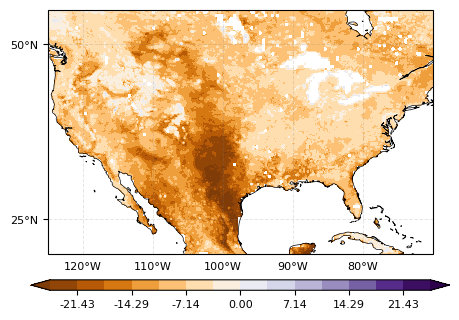

In [6]:
si_H_file = f'{path_data}sensitivity_index_SI_H_GLEAM_US.nc'
ds=xr.open_dataset(si_H_file)
ds=ds.sel(month=slice(6, 8))
si_H_summer = np.nanmean(ds.SI, axis=0)
maps(ds.lon, ds.lat, -25, 25, si_H_summer, "PuOr", f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20,55], topography = True, center_lon=210)



/tmp/ipykernel_1144480/894046231.py:4: RuntimeWarning: Mean of empty slice
  si_H_EOF3_lateMay = np.nanmean(ds.SI, axis=0)


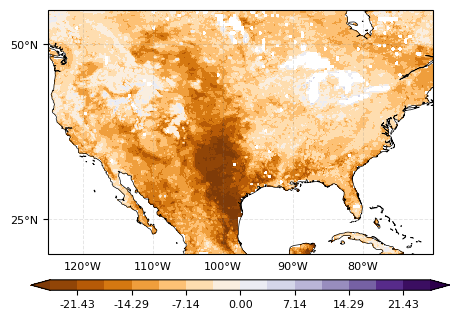

In [68]:
si_H_file = f'{path_data}sensitivity_index_SI_H_GLEAM_US_EOF3neg_lateMay_thresh0.75.nc'
ds=xr.open_dataset(si_H_file)
ds=ds.sel(month=slice(6, 8))
si_H_EOF3_lateMay = np.nanmean(ds.SI, axis=0)
maps(ds.lon, ds.lat, -25, 25, si_H_EOF3_lateMay, "PuOr", f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20,55], topography = True, center_lon=210)



/tmp/ipykernel_1144480/2650873168.py:4: RuntimeWarning: Mean of empty slice
  si_H_EOF3_lateApr = np.nanmean(ds.SI, axis=0)


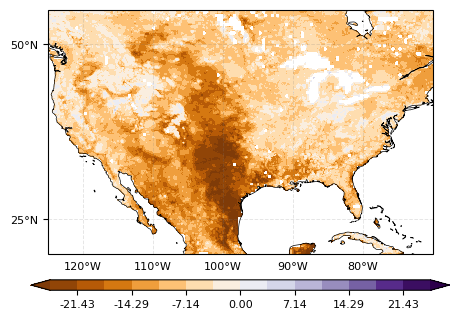

In [69]:
si_H_file = f'{path_data}sensitivity_index_SI_H_GLEAM_US_EOF3neg_lateApr_thresh0.75.nc'
ds=xr.open_dataset(si_H_file)
ds=ds.sel(month=slice(6, 8))
si_H_EOF3_lateApr = np.nanmean(ds.SI, axis=0)
maps(ds.lon, ds.lat, -25, 25, si_H_EOF3_lateApr, "PuOr", f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20,55], topography = True, center_lon=210)



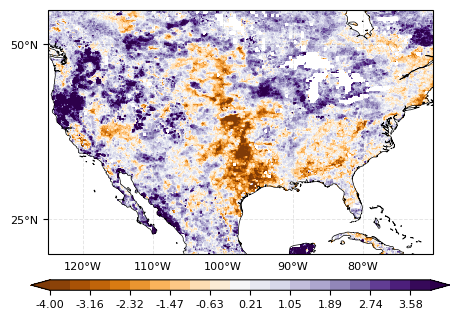

In [77]:
diff= si_H_EOF3_lateMay - si_H_summer
maps(ds.lon, ds.lat, -4, 4, diff, "PuOr", f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20,55], topography = True, center_lon=210, steps=20)


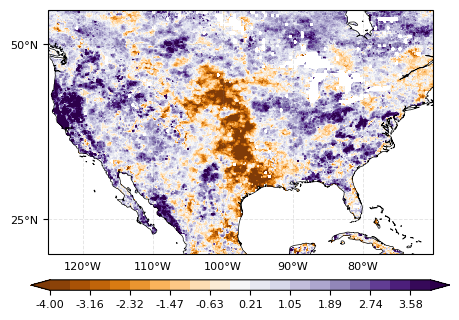

In [78]:
diff= si_H_EOF3_lateApr - si_H_summer
maps(ds.lon, ds.lat, -4, 4, diff, "PuOr", f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20,55], topography = True, center_lon=210, steps=20)


/tmp/ipykernel_466907/3695872512.py:4: RuntimeWarning: Mean of empty slice
  si_EF_summer = np.nanmean(ds.SI, axis=0)


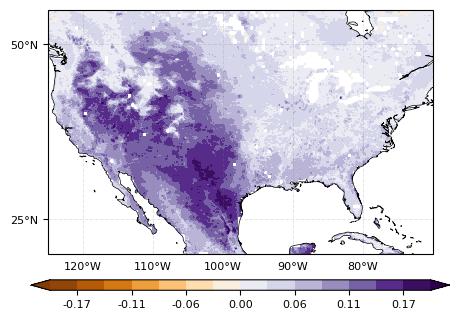

In [15]:
si_EF_file = f'{path_data}sensitivity_index_SI_EF_GLEAM_US.nc'
ds=xr.open_dataset(si_EF_file)
ds=ds.sel(month=slice(6, 8))
si_EF_summer = np.nanmean(ds.SI, axis=0)
maps(ds.lon, ds.lat, -0.20, 0.20, si_EF_summer, "PuOr", f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20,55], topography = True, center_lon=210)



## Regimes

In [55]:
ncfilenm=path_data + '/BP_SMsxEF_' + name + '_JJA_optimized.nc'
ds = xr.open_dataset(ncfilenm)

BIC = np.array(ds['BIC'])[0]   # shape (5, nlat, nlon)

# Replace miss_val with NaN before argmin
BIC_clean = np.where(np.isclose(BIC, -9.99e8), np.nan, BIC)

# argmin finds the MOST negative value = best model
best_model = np.full((len(lat_SMs), len(lon_SMs)), -1, dtype=int)
valid = np.sum(np.isfinite(BIC_clean), axis=0) > 0
best_model[valid] = np.nanargmin(BIC_clean[:, valid], axis=0)

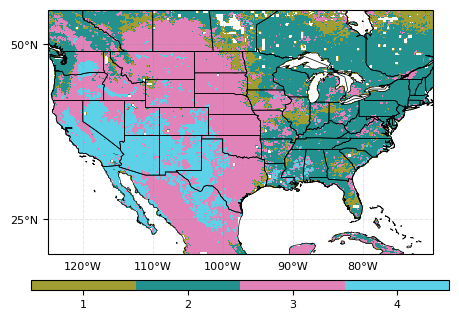

In [56]:
colors = [  
          '#FFA500',    # lavender
          '#029386',    # teal
          '#FF81C0',    # pink
          '#00FFFF']   # azure

li_reg, ls_reg, steps_reg, colormap_reg = colormap_custom(1,4,5,colors[:])
maps_classification(lon_SMs_360, lat_SMs, li_reg, ls_reg, best_model, colormap_reg, f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210)


plotting scatter


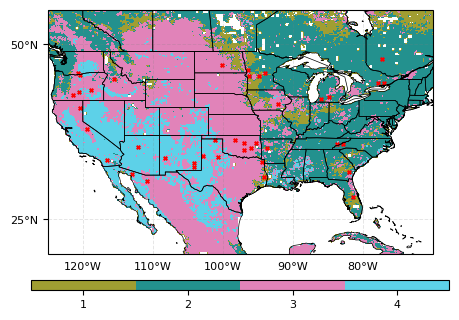

In [57]:
name_file_posHW = f'Heat_waves_events_list.csv'
df_heatwaves = pd.read_csv(f'/home/castanev/land_atmosphere/ERA5_P95_US_detrended_object/{name_file_posHW}', index_col=0)
datesHW_day0_str = df_heatwaves.iloc[:, 0].values
datesHW_day0 = np.array([dt.datetime.strptime(d, '%Y-%m-%d') for d in datesHW_day0_str])
pos_SM_events = np.where(datesHW_day0 >= dt.datetime(1980, 1, 1))[0]
coord_events = df_heatwaves.iloc[:, 4]
coord_events = coord_events.iloc[pos_SM_events]
lats_events, lons_events = extract_latlons_from_coord_events(coord_events)

coord_events_max = df_heatwaves.iloc[:, 5]
coord_events_max = coord_events_max.iloc[pos_SM_events]
lats_events_max, lons_events_max = extract_latlons_from_coord_events(coord_events_max)


maps_classification(lon_SMs_360, lat_SMs, li_reg, ls_reg, best_model, colormap_reg, f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events, y_scatter=lats_events)

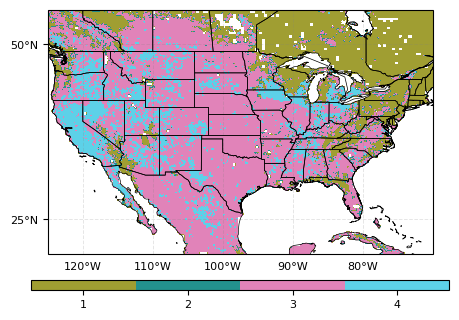

In [58]:
ncfilenm=path_data + '/BP_SMsxLE_' + name + '_JJA_optimized.nc'
ds = xr.open_dataset(ncfilenm)

BIC = np.array(ds['BIC'])[0]   # shape (5, nlat, nlon)

# Replace miss_val with NaN before argmin
BIC_clean = np.where(np.isclose(BIC, -9.99e8), np.nan, BIC)

# argmin finds the MOST negative value = best model
best_model = np.full((len(lat_SMs), len(lon_SMs)), -1, dtype=int)
valid = np.sum(np.isfinite(BIC_clean), axis=0) > 0
best_model[valid] = np.nanargmin(BIC_clean[:, valid], axis=0)

colors = [
          '#FFA500',    # lavender
          '#029386',    # teal
          '#FF81C0',    # pink
          '#00FFFF']   # azure

li_reg, ls_reg, steps_reg, colormap_reg = colormap_custom(1,4,5,colors[:])
maps_classification(lon_SMs_360, lat_SMs, li_reg, ls_reg, best_model, colormap_reg, f'map.png', xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210)


In [59]:
miss = -9.99e8
slope_1seg = np.array(ds["Slope_1Seg"])[0]
slope_valid = np.where(np.isclose(slope_1seg, miss), np.nan, slope_1seg)
abs_slope = np.abs(slope_valid)
linear = best_model == 1
sl = abs_slope[linear]
sl = sl[np.isfinite(sl)]
for p in [50, 75, 90, 95, 99]:
    print(f"p{p}: {np.nanpercentile(sl, p):.1f}")


p50: 185.3
p75: 359.3
p90: 552.6
p95: 1258.1
p99: 1974.6


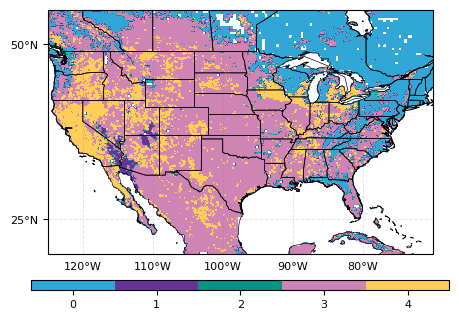

In [60]:
ncfilenm = path_data + '/BP_SMsxLE_' + name + '_JJA_optimized.nc'
ds = xr.open_dataset(ncfilenm)
BIC = np.array(ds['BIC'])[0]  # (5, nlat, nlon)
# Replace miss_val with NaN before argmin
BIC_clean = np.where(np.isclose(BIC, -9.99e8), np.nan, BIC)
# Best model option (0..4)
best_model = np.full((len(lat_SMs), len(lon_SMs)), -1, dtype=int)
valid = np.sum(np.isfinite(BIC_clean), axis=0) > 0
best_model[valid] = np.nanargmin(BIC_clean[:, valid], axis=0)
# Reclassify option 1 using slope threshold
# - keep class 1 only when slope <= 30  (wet-like)
# - assign class 5 when option 1 and slope > 30 (transitional-only)
slope_1seg = np.array(ds["Slope_1Seg"])[0]
slope_valid = np.where(np.isclose(slope_1seg, -9.99e8), np.nan, slope_1seg)
regime_map = best_model.copy()
opt1 = regime_map == 1
# option 1 -> class 5 if |slope| > 30 (transitional-only)
regime_map[opt1 & np.isfinite(slope_valid) & (slope_valid > 500)] = 1
# option 1 stays class 1 if |slope| <= 30 (wet-like linear)
regime_map[opt1 & np.isfinite(slope_valid) & (slope_valid <= 500)] = 0
colors = ['#00FFFF',
          '#7E1E9C',    
          '#029386',    # teal
          '#FF81C0',    # pink
          '#FFFF14']   # azure
li_reg, ls_reg, steps_reg, colormap_reg = colormap_custom(0, 4, 5, colors[:])
maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210
)

In [61]:
ncfilenm = path_data + '/map_wet_regime_fraction_GLEAM_US.nc'
ds = xr.open_dataset(ncfilenm)
best_model = np.array(ds["best_model"])

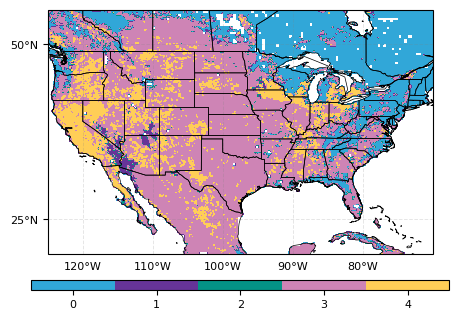

In [62]:
ncfilenm = path_data + '/map_wet_regime_fraction_GLEAM_US.nc'
ds = xr.open_dataset(ncfilenm)
best_model = np.array(ds["best_model"])
r2 = np.array(ds["R2_best_model"])
valid_slope_1seg = np.array(ds["valid_slope_1seg"])

regime_map = best_model.copy()


opt1 = regime_map == 1
# option 1 -> class 5 if |slope| > 30 (transitional-only)
regime_map[opt1 & np.isfinite(valid_slope_1seg) & (valid_slope_1seg > 0)] = 1
# option 1 stays class 1 if |slope| <= 30 (wet-like linear)
regime_map[opt1 & np.isfinite(valid_slope_1seg) & (valid_slope_1seg <= 0)] = 0


colors = ['#00FFFF',
          '#7E1E9C',    
          '#029386',    # teal
          '#FF81C0',    # pink
          '#FFFF14']   # azure
li_reg, ls_reg, steps_reg, colormap_reg = colormap_custom(0, 4, 5, colors[:])
maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210
)

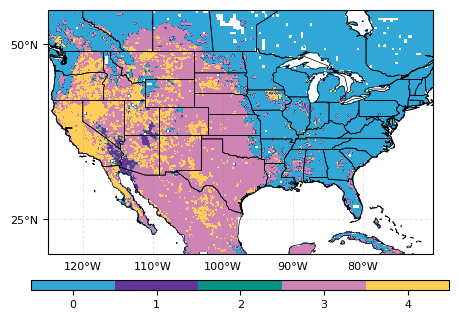

In [63]:
ncfilenm = path_data + '/map_wet_regime_fraction_GLEAM_US.nc'
ds = xr.open_dataset(ncfilenm)
best_model = np.array(ds["best_model"])
r2 = np.array(ds["R2_best_model"])
valid_slope_1seg = np.array(ds["valid_slope_1seg"])

regime_map = best_model.copy()
regime_map[r2<0.1] = 0

opt1 = regime_map == 1
# option 1 -> class 5 if |slope| > 30 (transitional-only)
regime_map[opt1 & np.isfinite(valid_slope_1seg) & (valid_slope_1seg > 0)] = 1
# option 1 stays class 1 if |slope| <= 30 (wet-like linear)
regime_map[opt1 & np.isfinite(valid_slope_1seg) & (valid_slope_1seg <= 0)] = 0


colors = ['#00FFFF',
          '#7E1E9C',    
          '#029386',    # teal
          '#FF81C0',    # pink
          '#FFFF14']   # azure
li_reg, ls_reg, steps_reg, colormap_reg = colormap_custom(0, 4, 5, colors[:])
maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210
)

In [16]:
datesHW_day0[pos_SM_events].shape

(41,)

plotting scatter


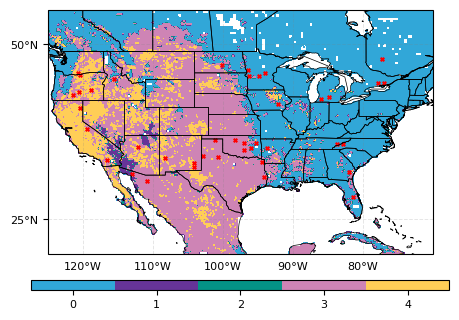

In [64]:
maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events, y_scatter=lats_events
)



plotting scatter


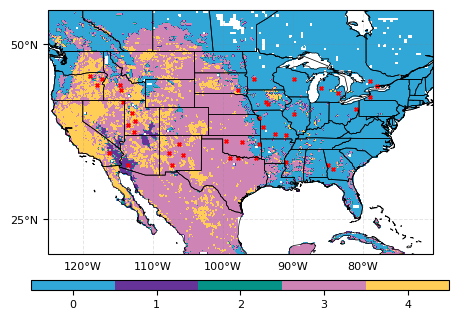

In [65]:
maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events_max, y_scatter=lats_events_max
)



In [26]:
lateApr_eof3_neg = df_heatwaves['LateApri_EOF3']
lateApr_eof3_neg = lateApr_eof3_neg.iloc[pos_SM_events]

lateApr_eof2or3_neg = df_heatwaves['LateApri_EOF2or3']
lateApr_eof2or3_neg = lateApr_eof2or3_neg.iloc[pos_SM_events]

In [27]:
datesHW_day0_SM = datesHW_day0[pos_SM_events]
datesHW_day0_lateApr = datesHW_day0_SM[lateApr_eof3_neg]
pos_JJ = np.where(
    np.array([d.month in (6, 7) for d in datesHW_day0_lateApr])
)[0]

In [69]:
datesHW_day0_lateApr


array([datetime.datetime(1980, 6, 24, 0, 0),
       datetime.datetime(1980, 7, 26, 0, 0),
       datetime.datetime(1981, 7, 14, 0, 0),
       datetime.datetime(1996, 6, 3, 0, 0),
       datetime.datetime(1996, 8, 11, 0, 0),
       datetime.datetime(2000, 8, 26, 0, 0),
       datetime.datetime(2003, 6, 23, 0, 0),
       datetime.datetime(2003, 8, 15, 0, 0),
       datetime.datetime(2006, 7, 21, 0, 0),
       datetime.datetime(2011, 6, 3, 0, 0),
       datetime.datetime(2011, 7, 31, 0, 0),
       datetime.datetime(2011, 8, 27, 0, 0),
       datetime.datetime(2012, 6, 25, 0, 0),
       datetime.datetime(2012, 7, 30, 0, 0),
       datetime.datetime(2017, 6, 18, 0, 0)], dtype=object)

In [28]:
lons_events_lateApr = lons_events[lateApr_eof3_neg]
lats_events_lateApr = lats_events[lateApr_eof3_neg]

lons_events_max_lateApr = lons_events_max[lateApr_eof3_neg]
lats_events_max_lateApr = lats_events_max[lateApr_eof3_neg]

lat_minHW = 25; lat_maxHW = 40; lon_minHW = 252; lon_maxHW = 270
pos_central = np.where(
    (lons_events_lateApr > lon_minHW) & (lons_events_lateApr < lon_maxHW)
    & (lats_events_lateApr > lat_minHW) & (lats_events_lateApr < lat_maxHW)
)[0]

pos_central_max = np.where(
    (lons_events_max_lateApr > lon_minHW) & (lons_events_max_lateApr < lon_maxHW)
    & (lats_events_max_lateApr > lat_minHW) & (lats_events_max_lateApr < lat_maxHW)
)[0]

plotting scatter


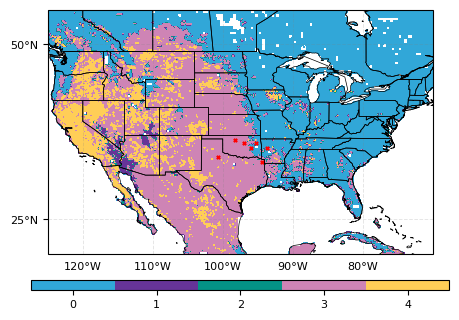

In [29]:

maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events_lateApr[pos_central], y_scatter=lats_events_lateApr[pos_central]
)

plotting scatter


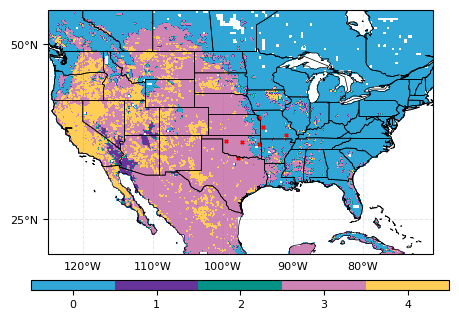

In [30]:

maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events_max_lateApr[pos_central_max], y_scatter=lats_events_max_lateApr[pos_central_max]
)

In [71]:
lons_events_lateApr = lons_events[lateApr_eof2or3_neg]
lats_events_lateApr = lats_events[lateApr_eof2or3_neg]

lat_minHW = 25; lat_maxHW = 40; lon_minHW = 252; lon_maxHW = 270
pos_central = np.where(
    (lons_events_lateApr > lon_minHW) & (lons_events_lateApr < lon_maxHW)
    & (lats_events_lateApr > lat_minHW) & (lats_events_lateApr < lat_maxHW)
)[0]

plotting scatter


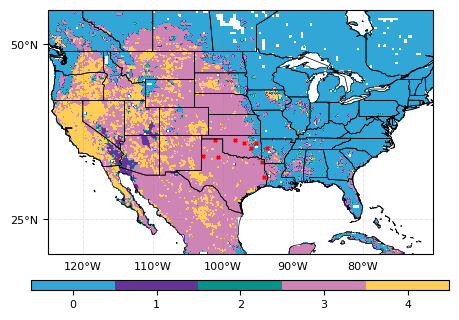

In [72]:

maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events_lateApr[pos_central], y_scatter=lats_events_lateApr[pos_central]
)

plotting scatter


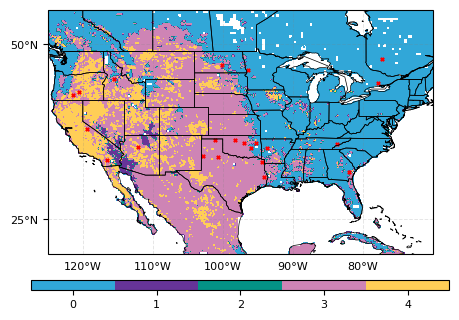

In [73]:

maps_classification(
    lon_SMs_360, lat_SMs, li_reg, ls_reg, regime_map, colormap_reg, f'map.png',
    xlim=[235 - 210, 290 - 210], ylim=[20, 55], topography=True, center_lon=210, x_scatter=lons_events_lateApr, y_scatter=lats_events_lateApr
)

In [27]:
Slope_1Seg=np.array(ds['Slope_1Seg'])[0]

In [30]:
slopes_linear = Slope_1Seg[best_model==1]

### EOF

In [3]:
path_eof = f'/scratch/negishi/castanev/GLEAM/EOF_timeseries_monthly_anoma_SMrz_GLEAM_May_US.nc'
ds_eof = xr.open_dataset(path_eof)
eof_ts = ds_eof['n_pc']
eof_n = ds_eof['n_eof']
time_ymd = ds_eof['time_ymd']



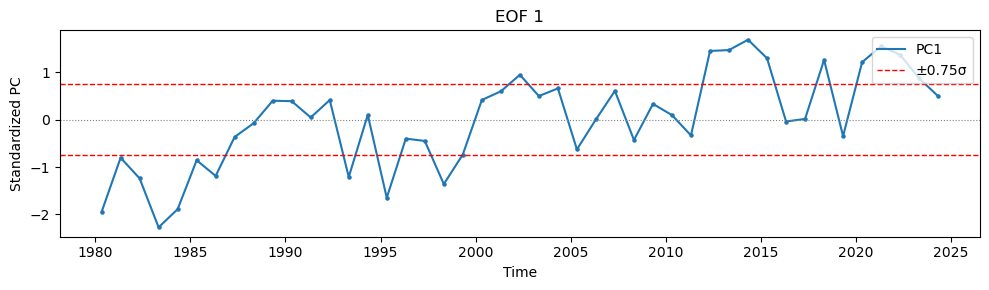

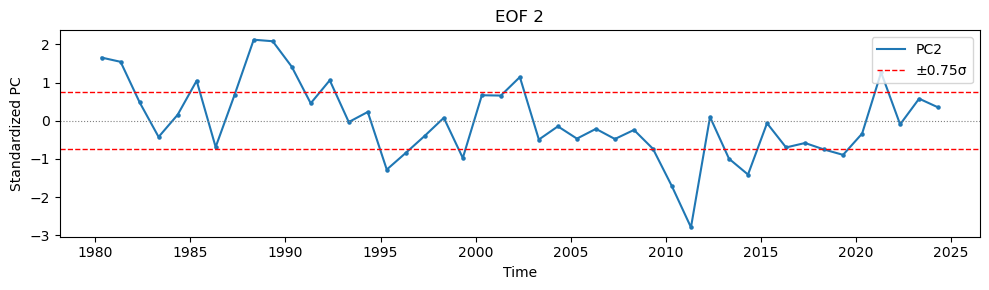

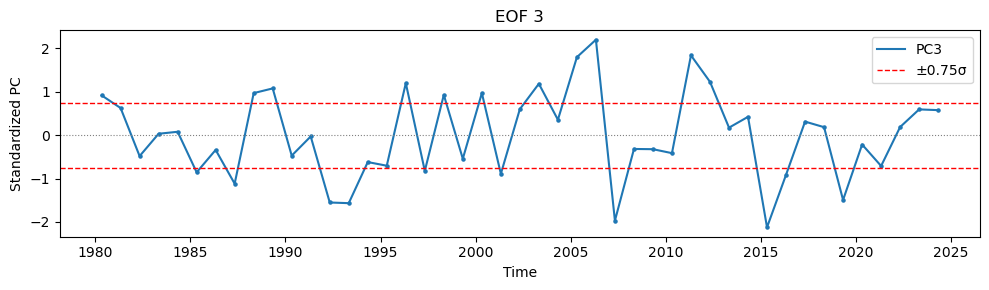

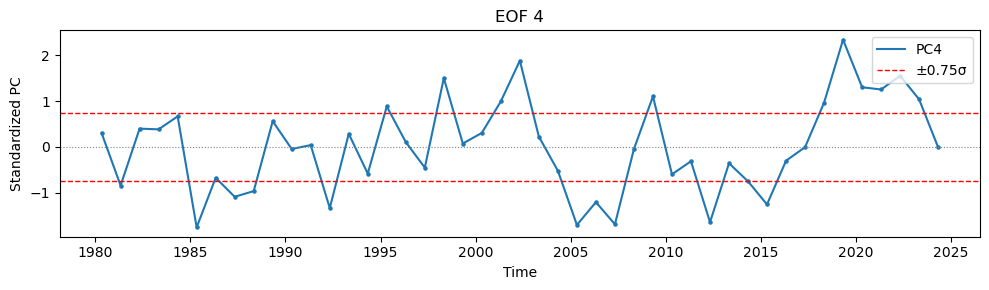

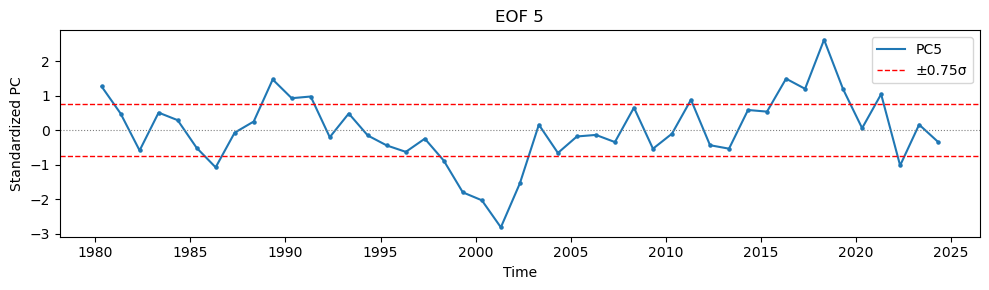

In [5]:
# Standardize each PC: (PC - mean) / std
t_dim = eof_ts.dims[-1]
eof_ts_std = (eof_ts - eof_ts.mean(t_dim)) / eof_ts.std(t_dim)
# Readable time axis from YYYYMMDD integers
time = pd.to_datetime(time_ymd.values.astype(str), format="%Y%m%d")

for i in range(eof_ts_std.shape[0]):
    plt.figure(figsize=(10, 3))
    plt.plot(time, eof_ts_std[i].values, label=f"PC{i+1}")
    plt.scatter(time, eof_ts_std[i].values, s=5)
    plt.axhline(0.75, color="red", linestyle="--", lw=1, label="±0.75σ")
    plt.axhline(-0.75, color="red", linestyle="--", lw=1)
    # plt.axhline(0.5, color="black", linestyle="--", lw=0.5, label="±0.5σ")
    # plt.axhline(-0.5, color="black", linestyle="--", lw=0.5)
    plt.axhline(0, color="gray", linestyle=":", lw=0.8)
    plt.title(f"EOF {i+1}")
    plt.xlabel("Time")
    plt.ylabel("Standardized PC")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
datesHW_day0_SM = datesHW_day0[pos_SM_events]
datesHW_day0_lateApr = datesHW_day0_SM[lateApr_eof3_neg]
pos_JJ = np.where(
    np.array([d.month in (6, 7) for d in datesHW_day0_lateApr])
)[0]


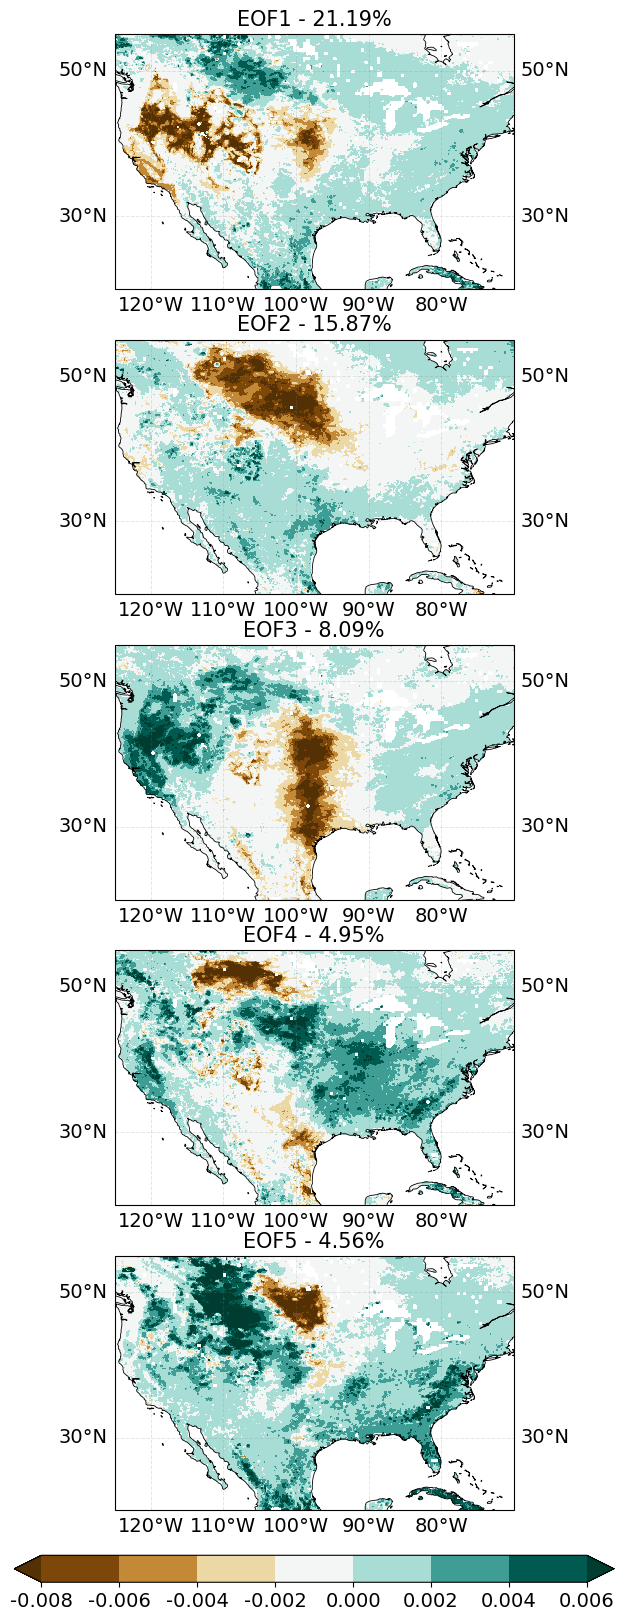

In [ ]:
pcvar_n = [float(value) for value in list(ds_eof['n_eof'].pcvar)]
maps_EOF(eof_n[:, :, :], lat_SMs[:], lon_SMs, -0.008, 0.008, 'BrBG', pcvar_n, f'EOF_anom.png', True, r'')

In [43]:
path_eof = f'/scratch/negishi/castanev/GLEAM/EOF_timeseries_daily_anoma_window_smoothed15daysw_SMrz_GLEAM_AprMay_US.nc'
ds_eof = xr.open_dataset(path_eof)
eof_ts = ds_eof['n_pc']
eof_n = ds_eof['n_eof']
time_ymd = ds_eof['time_ymd']



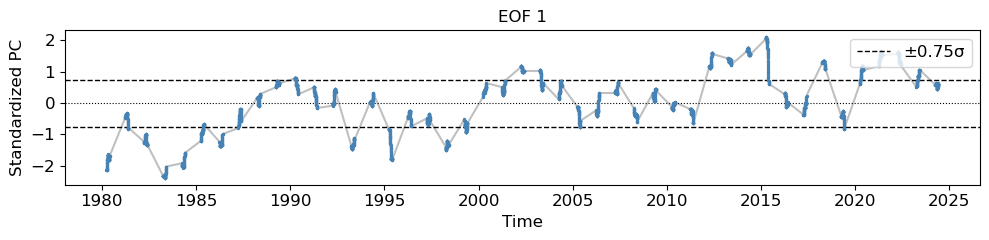

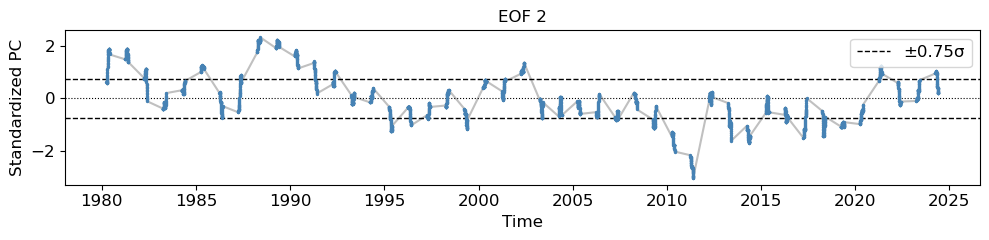

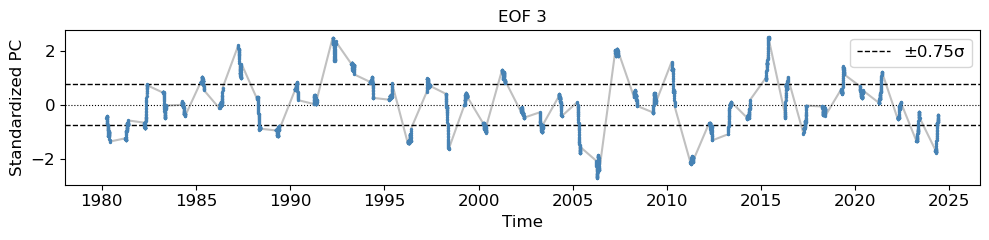

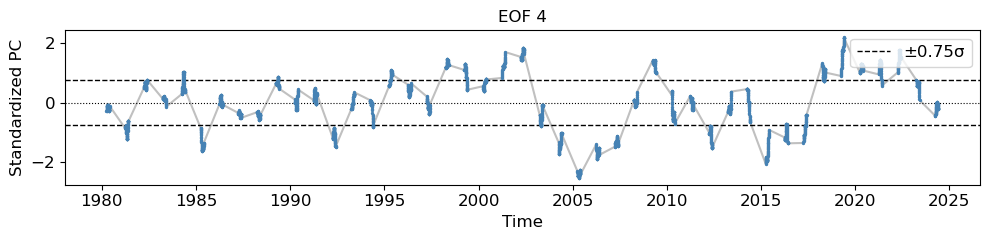

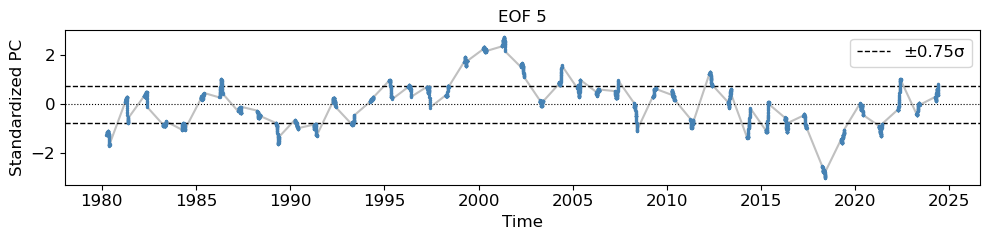

In [44]:
# Standardize each PC: (PC - mean) / std
t_dim = eof_ts.dims[-1]
eof_ts_std = (eof_ts - eof_ts.mean(t_dim)) / eof_ts.std(t_dim)
# Readable time axis from YYYYMMDD integers
time = pd.to_datetime(time_ymd.values.astype(str), format="%Y%m%d")

for i in range(eof_ts_std.shape[0]):
    plt.figure(figsize=(10, 2.5))
    plt.plot(time, eof_ts_std[i].values, color="silver", zorder=1)
    plt.scatter(time, eof_ts_std[i].values, s=2, color="steelblue", zorder=2.5)
    plt.axhline(0.75, color="k", linestyle="--", lw=1, label="±0.75σ")
    plt.axhline(-0.75, color="k", linestyle="--", lw=1)
    # plt.axhline(0.5, color="black", linestyle="--", lw=0.5, label="±0.5σ")
    # plt.axhline(-0.5, color="black", linestyle="--", lw=0.5)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.axhline(0, color="k", linestyle=":", lw=0.8)
    plt.title(f"EOF {i+1}", fontsize=12)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Standardized PC", fontsize=12)
    plt.legend(loc="upper right", fontsize=12)
    plt.tight_layout()
    plt.show()

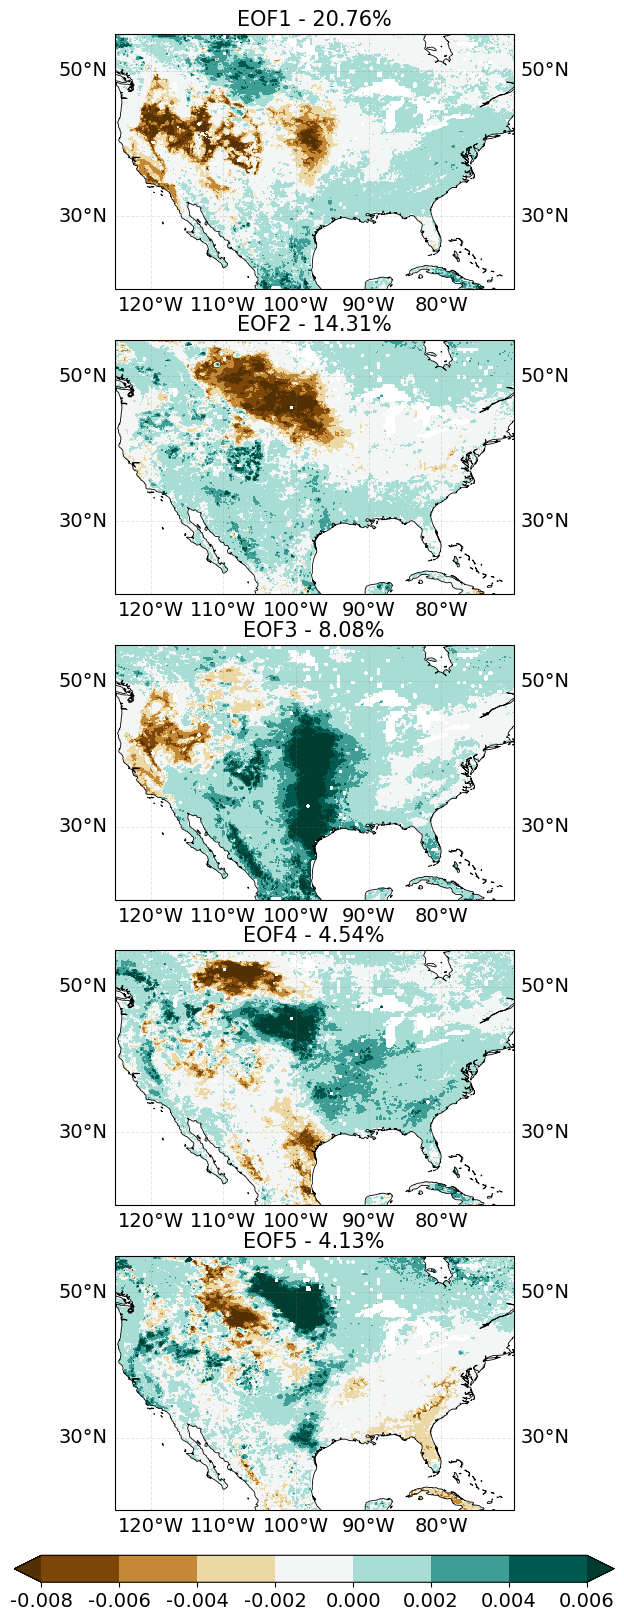

In [9]:
pcvar_n = [float(value) for value in list(ds_eof['n_eof'].pcvar)]
maps_EOF(eof_n[:, :, :], lat_SMs[:], lon_SMs, -0.008, 0.008, 'BrBG', pcvar_n, f'EOF_anom.png', True, r'')

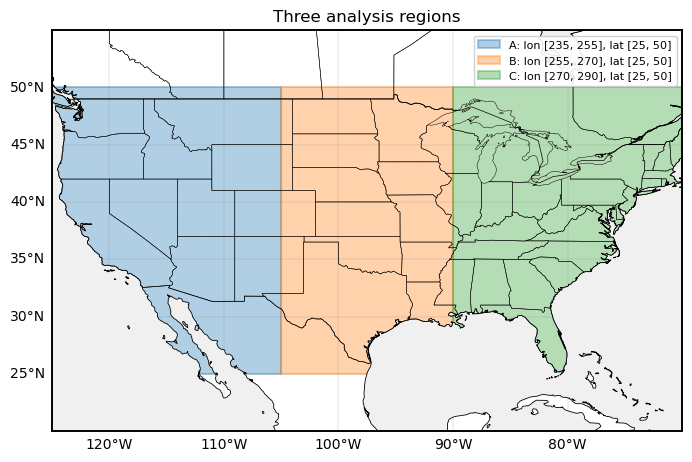

In [89]:
# --- edit these (3 regions; lon in 0–360°E) ---
# Region A
A_min_lat, A_max_lat = 25.0, 50
A_min_lon, A_max_lon = 235.0, 255.0   # west
# Region B
B_min_lat, B_max_lat = 25.0, 50
B_min_lon, B_max_lon = 255.0, 270.0   # south-central
# Region C
C_min_lat, C_max_lat = 25.0, 50
C_min_lon, C_max_lon = 270.0, 290.0   # east
# map extent (US)
map_lon_min, map_lon_max = 235.0, 290.0
map_lat_min, map_lat_max = 20.0, 55.0
# colors / opacity for the 3 shaded regions
A_color, B_color, C_color = 'C0', 'C1', 'C2'
shade_alpha = 0.35
# ------------------

from matplotlib.patches import Rectangle
from cartopy import crs

center_lon = 210
xlim = [map_lon_min - center_lon, map_lon_max - center_lon]
ylim = [map_lat_min, map_lat_max]

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(1, 1, 1, projection=crs.PlateCarree(central_longitude=center_lon))

# Land under the boxes
ax.add_feature(cartopy.feature.LAND, facecolor='white', edgecolor='none', zorder=0)

regions = [
    ('A', A_min_lon, A_max_lon, A_min_lat, A_max_lat, A_color),
    ('B', B_min_lon, B_max_lon, B_min_lat, B_max_lat, B_color),
    ('C', C_min_lon, C_max_lon, C_min_lat, C_max_lat, C_color),
]
for name, lon0, lon1, lat0, lat1, color in regions:
    ax.add_patch(Rectangle(
        (lon0, lat0), lon1 - lon0, lat1 - lat0,
        facecolor=color, edgecolor=color, linewidth=1.5,
        alpha=shade_alpha, zorder=2,
        transform=crs.PlateCarree(),
        label=f'{name}: lon [{lon0:g}, {lon1:g}], lat [{lat0:g}, {lat1:g}]',
    ))

# Ocean on top of boxes so shading only shows over land
ax.add_feature(cartopy.feature.OCEAN, facecolor='#f0f0f0', edgecolor='none', zorder=3)
ax.add_feature(cartopy.feature.COASTLINE, lw=0.6, zorder=5)
ax.add_feature(cartopy.feature.BORDERS, lw=0.5, zorder=5)
ax.add_feature(cartopy.feature.STATES, lw=0.35, zorder=5)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title('Three analysis regions')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
gl = ax.gridlines(crs=crs.PlateCarree(), draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.right_labels = False
gl.top_labels = False

# Make map frame (incl. left border) visible above ocean/land
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor('k')
    spine.set_zorder(20)
if hasattr(ax, 'outline_patch') and ax.outline_patch is not None:
    ax.outline_patch.set_visible(True)
    ax.outline_patch.set_linewidth(1.2)
    ax.outline_patch.set_edgecolor('k')
    ax.outline_patch.set_zorder(20)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.08, top=0.92)
plt.show()


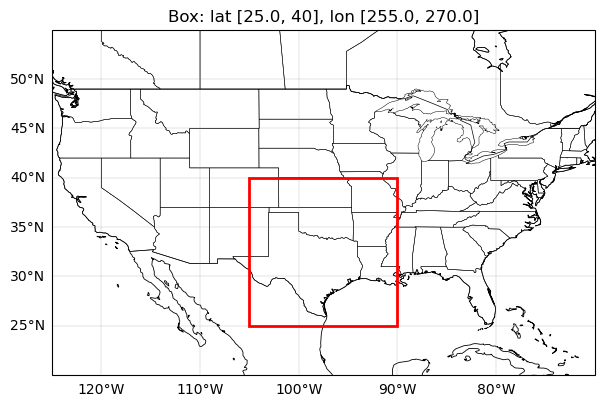

In [83]:
# --- edit these ---
min_lat, max_lat = 25.0, 40
min_lon, max_lon = 255.0, 270.0   # 0–360°E  (252 = −108°W, 270 = −90°W)
# map extent (US)
map_lon_min, map_lon_max = 235.0, 290.0
map_lat_min, map_lat_max = 20.0, 55.0
# ------------------

from matplotlib.patches import Rectangle
from cartopy import crs

center_lon = 210
# xlim in display coords (same convention as your maps() helper)
xlim = [map_lon_min - center_lon, map_lon_max - center_lon]
ylim = [map_lat_min, map_lat_max]

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(1, 1, 1, projection=crs.PlateCarree(central_longitude=center_lon))
ax.add_feature(cartopy.feature.COASTLINE, lw=0.6)
ax.add_feature(cartopy.feature.BORDERS, lw=0.5)
ax.add_feature(cartopy.feature.STATES, lw=0.35)

ax.add_patch(Rectangle(
    (min_lon, min_lat),
    max_lon - min_lon,
    max_lat - min_lat,
    fill=False, edgecolor='red', linewidth=2, zorder=10,
    transform=crs.PlateCarree(),
))

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title(f'Box: lat [{min_lat}, {max_lat}], lon [{min_lon}, {max_lon}]')
gl = ax.gridlines(crs=crs.PlateCarree(), draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.right_labels = False
gl.top_labels = False
plt.show()


In [ ]:
plot